# Análisis, Descripción, Preparación y Limpieza de 9 Datasets
## Notebook Completo – Ciencia de Datos Aplicada

| # | Dataset | Tipo de Problema | Variable Objetivo |
|---|---------|-----------------|-------------------|
| 1 | Ames Housing | Regresión | `SalePrice` |
| 2 | MIMIC-III | Clasificación | Mortalidad en UCI |
| 3 | NHANES 2021-23 | Clasificación | Diabetes |
| 4 | Bike Sharing | Regresión | `count` (demanda) |
| 5 | Adult Census Income | Clasificación | Ingresos >50K |
| 6 | Credit Approval (UCI) | Clasificación | Aprobación crédito |
| 7 | Australian Credit | Clasificación | Aprobación crédito |
| 8 | Breast Cancer Wisconsin | Clasificación | Malignidad |
| 9 | Meningitis | Clasificación | Diagnóstico |

> **Nota sobre descarga:** Cada sección incluye instrucciones precisas para obtener los datos desde su fuente oficial.


## Instalación de Dependencias

In [2]:
# ── Imports globales ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import warnings
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Estilo global ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 5)})

# ── Función de reporte rápido ─────────────────────────────────
def quick_report(df, name="Dataset"):
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    miss_df = pd.DataFrame({'Nulos': miss, '%': miss_pct})
    miss_df = miss_df[miss_df['Nulos'] > 0].sort_values('%', ascending=False)
    if len(miss_df):
        print(f"\n  Columnas con valores nulos ({len(miss_df)}):")
        print(miss_df.head(15).to_string())
    else:
        print("  Sin valores nulos ✓")
    print(f"\n  Duplicados: {df.duplicated().sum():,}")
    print()

def plot_missing(df, title="Mapa de Valores Faltantes"):
    fig, ax = plt.subplots(figsize=(14, 4))
    msno.matrix(df, ax=ax, sparkline=False, color=(0.27, 0.52, 0.71))
    ax.set_title(title, fontsize=13, pad=10)
    plt.tight_layout()
    plt.show()

def plot_numeric_distributions(df, cols, title="Distribuciones Numéricas"):
    n = len(cols)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for i, c in enumerate(cols):
        axes[0, i].hist(df[c].dropna(), bins=30, color='steelblue', edgecolor='white')
        axes[0, i].set_title(c, fontsize=9)
        axes[1, i].boxplot(df[c].dropna(), vert=True, patch_artist=True,
                           boxprops=dict(facecolor='steelblue', alpha=0.6))
        axes[1, i].set_title(f'{c} – Boxplot', fontsize=9)
    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


---
# 1️⃣ Ames Housing Dataset
**Problema:** Regresión – predecir el precio de venta (`SalePrice`) de viviendas en Ames, Iowa (2006-2010).  
**Fuente:** Kaggle – https://www.kaggle.com/datasets/marcopale/housing  
**Descarga:**
```bash
# Opción A – Kaggle CLI (requiere API key)
kaggle datasets download -d marcopale/housing --unzip -p data/ames/

# Opción B – Manual: descargar train.csv / test.csv desde la URL y guardar en data/ames/
```


In [3]:
# ── 1.1  Carga ────────────────────────────────────────────────
AMES_PATH = 'dataset_p1/1amesHhousingDataset/train.csv'   # ajusta si cambia la ruta

try:
    ames = pd.read_csv(AMES_PATH)
    print(f"✅ Ames cargado: {ames.shape}")
except FileNotFoundError:
    print("⚠️  Archivo no encontrado. Descarga el dataset y colócalo en data/ames/train.csv")
    print("   URL: https://www.kaggle.com/datasets/marcopale/housing")
    import sys; sys.exit(0)


✅ Ames cargado: (2197, 82)


In [4]:
# ── 1.2  Vista general ────────────────────────────────────────
quick_report(ames, "Ames Housing – train.csv")
ames.head(3)


  Ames Housing – train.csv
  Filas: 2,197  |  Columnas: 82

  Columnas con valores nulos (27):
                Nulos      %
Pool QC          2185 99.450
Misc Feature     2117 96.360
Alley            2054 93.490
Fence            1778 80.930
Mas Vnr Type     1329 60.490
Fireplace Qu     1066 48.520
Lot Frontage      362 16.480
Garage Qual       122  5.550
Garage Cond       122  5.550
Garage Yr Blt     122  5.550
Garage Finish     122  5.550
Garage Type       120  5.460
Bsmt Exposure      69  3.140
BsmtFin Type 2     68  3.100
Bsmt Cond          67  3.050

  Duplicados: 0



,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,...,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.000,9605,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SawyerW,Norm,Norm,1Fam,1Story,7,6,2007,2007,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,Gd,TA,...,3,1,Gd,6,Typ,0,NaN,Detchd,2007.000,RFn,2.000,576.000,TA,TA,Y,0,178,0,0,0,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.000,14684,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,SawyerW,Norm,Norm,1Fam,1Story,7,7,1990,1991,Hip,CompShg,HdBoard,HdBoard,BrkFace,234.000,Gd,TA,...,3,1,Gd,7,Typ,1,TA,Attchd,1990.000,RFn,3.000,701.000,TA,TA,Y,84,70,0,0,0,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,NoSeWa,CulDSac,Gtl,Timber,Norm,Norm,1Fam,SLvl,6,6,1958,1958,Gable,CompShg,HdBoard,HdBoard,BrkFace,541.000,TA,TA,...,3,1,Gd,7,Typ,1,Gd,Basment,1958.000,RFn,2.000,525.000,TA,TA,Y,0,118,0,0,233,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500


In [5]:
# ── 1.3  Tipos de datos ───────────────────────────────────────
num_cols = ames.select_dtypes(include='number').columns.tolist()
cat_cols = ames.select_dtypes(include='object').columns.tolist()
print(f"Columnas numéricas : {len(num_cols)}")
print(f"Columnas categóricas: {len(cat_cols)}")
print("\nNúmericas:", num_cols[:10], "...")
print("Categóricas:", cat_cols[:10], "...")


Columnas numéricas : 39
Columnas categóricas: 43

Númericas: ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area'] ...
Categóricas: ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1'] ...


In [6]:
# ── 1.4  Estadísticas descriptivas ───────────────────────────
ames.describe(percentiles=[.01,.25,.5,.75,.99]).T


,count,mean,std,min,1%,25%,50%,75%,99%,max
Order,2197.000,1460.513,846.537,1.000,29.920,733.000,1452.000,2196.000,2903.040,2929.000
PID,2197.000,712787219.835,188775064.002,526301100.000,527106149.600,528441020.000,535453150.000,907181120.000,923252076.000,1007100110.000
MS SubClass,2197.000,57.064,42.361,20.000,20.000,20.000,50.000,70.000,190.000,190.000
Lot Frontage,1835.000,69.549,23.188,21.000,21.000,58.500,69.000,80.000,135.320,313.000
Lot Area,2197.000,10268.070,7975.741,1300.000,1889.160,7500.000,9488.000,11660.000,34669.320,215245.000
Overall Qual,2197.000,6.117,1.430,1.000,3.000,5.000,6.000,7.000,10.000,10.000
Overall Cond,2197.000,5.553,1.107,1.000,3.000,5.000,5.000,6.000,9.000,9.000
Year Built,2197.000,1972.031,30.450,1872.000,1897.920,1954.000,1975.000,2002.000,2008.040,2010.000
Year Remod/Add,2197.000,1984.781,20.898,1950.000,1950.000,1966.000,1994.000,2004.000,2009.000,2010.000
Mas Vnr Area,2175.000,105.102,184.897,0.000,0.000,0.000,0.000,166.000,827.440,1600.000


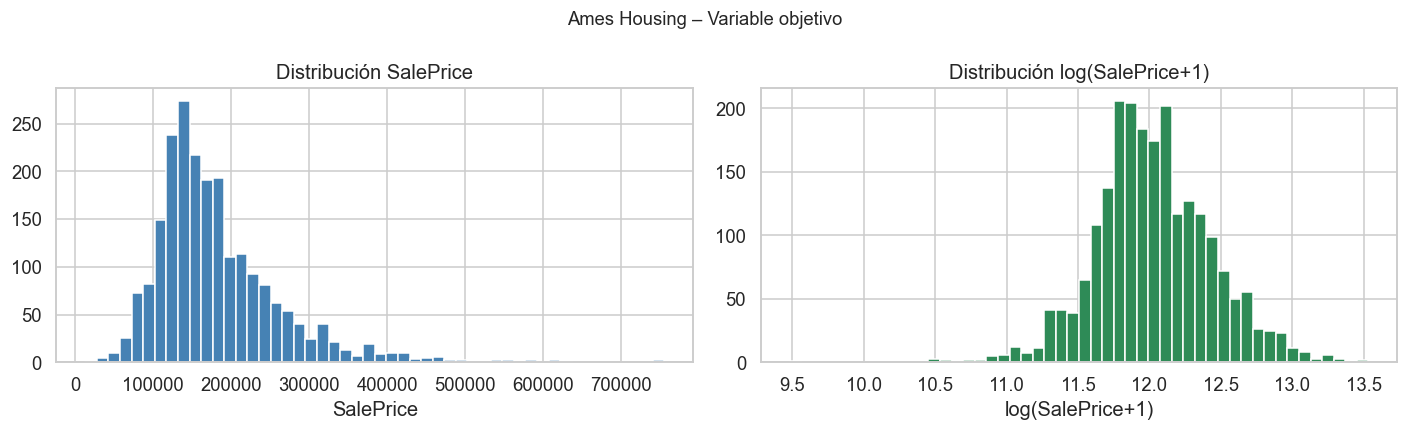

Skewness original : 1.779
Skewness log      : -0.003


In [7]:
# ── 1.5  Variable objetivo – SalePrice ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ames['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución SalePrice'); axes[0].set_xlabel('SalePrice')
axes[1].hist(np.log1p(ames['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribución log(SalePrice+1)'); axes[1].set_xlabel('log(SalePrice+1)')
plt.suptitle('Ames Housing – Variable objetivo', fontsize=12)
plt.tight_layout(); plt.show()

print(f"Skewness original : {ames['SalePrice'].skew():.3f}")
print(f"Skewness log      : {np.log1p(ames['SalePrice']).skew():.3f}")


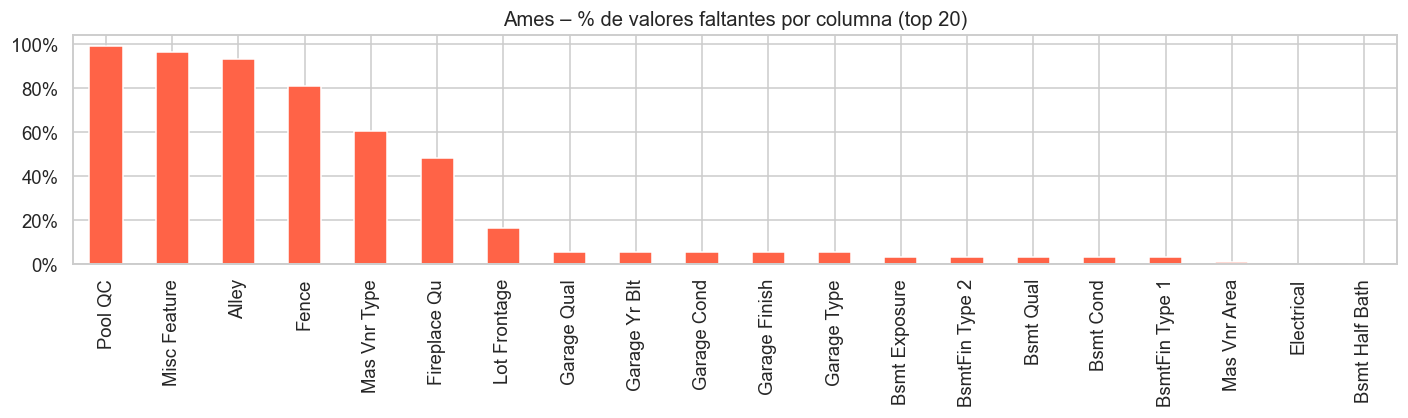

In [8]:
# ── 1.6  Mapa de valores faltantes ───────────────────────────
miss = ames.isnull().mean().sort_values(ascending=False)
miss_top = miss[miss > 0].head(20)

fig, ax = plt.subplots(figsize=(13, 4))
miss_top.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Ames – % de valores faltantes por columna (top 20)')
ax.set_xlabel('')
plt.tight_layout(); plt.show()


In [9]:
# ── 1.7  Limpieza y Preparación ──────────────────────────────
ames_clean = ames.copy()

# 1.7a  Columnas con >50% nulos → eliminar
high_miss = miss[miss > 0.5].index.tolist()
print(f"Columnas eliminadas (>50% nulos): {high_miss}")
ames_clean.drop(columns=high_miss, inplace=True)

# 1.7b  Valores nulos semánticos (NA significa "no tiene")
na_means_none = ['Alley','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1',
                 'BsmtFinType2','FireplaceQu','GarageType','GarageFinish',
                 'GarageQual','GarageCond','PoolQC','Fence','MiscFeature']
for col in na_means_none:
    if col in ames_clean.columns:
        ames_clean[col].fillna('None', inplace=True)

# 1.7c  Numéricos: mediana para LotFrontage; 0 para garage/bsmt
num_median_cols = ['LotFrontage']
for col in num_median_cols:
    if col in ames_clean.columns:
        ames_clean[col].fillna(ames_clean[col].median(), inplace=True)

zero_fill = ['GarageYrBlt','GarageArea','GarageCars',
             'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
             'BsmtFullBath','BsmtHalfBath','MasVnrArea']
for col in zero_fill:
    if col in ames_clean.columns:
        ames_clean[col].fillna(0, inplace=True)

# 1.7d  Categóricos restantes: moda
cat_remaining = ames_clean.select_dtypes('object').columns
for col in cat_remaining:
    if ames_clean[col].isnull().any():
        ames_clean[col].fillna(ames_clean[col].mode()[0], inplace=True)

# 1.7e  Outliers en GrLivArea (regla estándar del dataset)
if 'GrLivArea' in ames_clean.columns:
    before = len(ames_clean)
    ames_clean = ames_clean[~((ames_clean['GrLivArea'] > 4000) &
                               (ames_clean['SalePrice'] < 300000))]
    print(f"Filas eliminadas por outlier GrLivArea: {before - len(ames_clean)}")

# 1.7f  Transformación logarítmica de SalePrice
ames_clean['SalePrice_log'] = np.log1p(ames_clean['SalePrice'])

# 1.7g  Feature engineering básico
if {'TotalBsmtSF','1stFlrSF','2ndFlrSF'}.issubset(ames_clean.columns):
    ames_clean['TotalSF'] = ames_clean['TotalBsmtSF'] + ames_clean['1stFlrSF'] + ames_clean['2ndFlrSF']

if {'FullBath','HalfBath','BsmtFullBath','BsmtHalfBath'}.issubset(ames_clean.columns):
    ames_clean['TotalBath'] = (ames_clean['FullBath'] +
                                0.5 * ames_clean['HalfBath'] +
                                ames_clean['BsmtFullBath'] +
                                0.5 * ames_clean['BsmtHalfBath'])

if {'YrSold','YearBuilt'}.issubset(ames_clean.columns):
    ames_clean['HouseAge'] = ames_clean['YrSold'] - ames_clean['YearBuilt']

if {'YrSold','YearRemodAdd'}.issubset(ames_clean.columns):
    ames_clean['YearsSinceRemod'] = ames_clean['YrSold'] - ames_clean['YearRemodAdd']

print(f"\n✅ Ames limpio: {ames_clean.shape}")
print(f"   Nulos restantes: {ames_clean.isnull().sum().sum()}")


Columnas eliminadas (>50% nulos): ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type']

✅ Ames limpio: (2197, 78)
   Nulos restantes: 2405


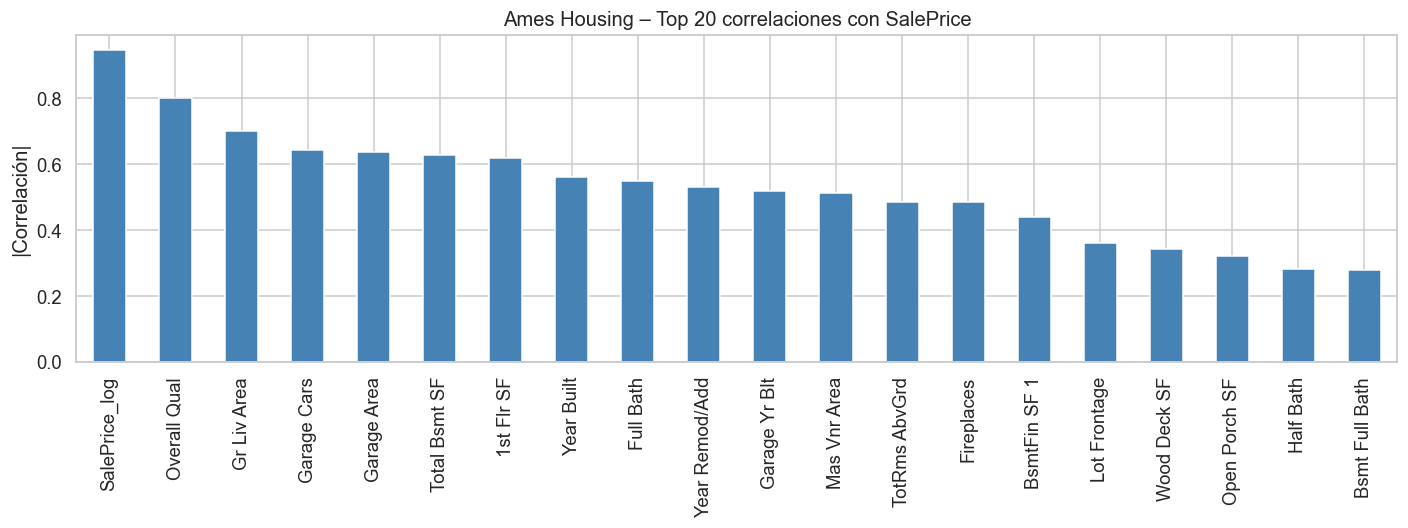

In [10]:
# ── 1.8  Correlación con SalePrice ───────────────────────────
num_clean = ames_clean.select_dtypes('number')
corr = num_clean.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
corr.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Ames Housing – Top 20 correlaciones con SalePrice')
ax.set_ylabel('|Correlación|')
plt.tight_layout(); plt.show()


In [11]:
# ── 1.9  Codificación de categóricas ─────────────────────────
ames_encoded = ames_clean.copy()
for col in ames_encoded.select_dtypes('object').columns:
    ames_encoded[col] = LabelEncoder().fit_transform(ames_encoded[col].astype(str))

print(f"✅ Ames codificado: {ames_encoded.shape}")
print("   Dataset listo para modelado.")
ames_encoded.head(3)


✅ Ames codificado: (2197, 78)
   Dataset listo para modelado.


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,...,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,SalePrice_log
0,534,531363010,20,5,80.000,9605,1,3,3,0,0,0,23,2,2,0,2,7,6,2007,2007,1,1,13,14,0.000,2,4,2,2,...,1,1,3,1,2,6,7,0,5,5,2007.000,1,2.000,576.000,4,4,2,0,178,0,0,0,0,0,4,2009,9,4,159000,11.977
1,803,906203120,20,5,90.000,14684,1,0,3,0,1,0,23,2,2,0,2,7,7,1990,1991,3,1,6,6,234.000,2,4,1,2,...,2,0,3,1,2,7,7,1,4,1,1990.000,1,3.000,701.000,4,4,2,84,70,0,0,0,0,0,6,2009,9,4,271900,12.513
2,956,916176030,20,5,NaN,14375,1,0,3,1,1,0,26,2,2,0,7,6,6,1958,1958,1,1,6,6,541.000,3,4,1,4,...,1,0,3,1,2,7,7,1,2,2,1958.000,1,2.000,525.000,4,4,2,0,118,0,0,233,0,0,1,2009,0,0,137500,11.831


---
# 2️⃣ MIMIC-III (Medical Information Mart for Intensive Care)
**Problema:** Clasificación – predecir **mortalidad hospitalaria** de pacientes en UCI.  
**Fuente:** PhysioNet Demo – https://physionet.org/content/mimiciii-demo/1.4/  
**Descarga:**
```bash
# Versión DEMO (libre, sin credenciales)
wget -r -N -c -np https://physionet.org/files/mimiciii-demo/1.4/ -P data/mimic/
# O descarga manual los archivos .csv.gz desde la URL y colócalos en data/mimic/
```
**Archivos a usar:** `ADMISSIONS.csv`, `PATIENTS.csv`, `ICUSTAYS.csv`, `LABEVENTS.csv`  
**Objetivo:** `HOSPITAL_EXPIRE_FLAG` (1=murió en hospital, 0=sobrevivió)


In [12]:
# ── 2.1  Carga de archivos MIMIC-III ─────────────────────────
MIMIC_PATH = 'dataset_p1/2mimic'

def load_mimic(fname):
    for ext in ['.csv', '.csv.gz']:
        path = os.path.join(MIMIC_PATH, fname + ext)
        if os.path.exists(path):
            return pd.read_csv(path, low_memory=False)
    return None

try:
    admissions = load_mimic('ADMISSIONS')
    patients   = load_mimic('PATIENTS')
    icustays   = load_mimic('ICUSTAYS')
    labevents  = load_mimic('LABEVENTS')

    if admissions is None:
        raise FileNotFoundError
    print("✅ MIMIC-III archivos cargados:")
    for name, df in [('ADMISSIONS', admissions), ('PATIENTS', patients),
                     ('ICUSTAYS', icustays), ('LABEVENTS', labevents)]:
        if df is not None:
            print(f"   {name}: {df.shape}")
except FileNotFoundError:
    print("⚠️  Archivos MIMIC-III no encontrados.")
    print("   Descarga la versión demo desde:")
    print("   https://physionet.org/content/mimiciii-demo/1.4/")
    admissions = patients = icustays = labevents = None


✅ MIMIC-III archivos cargados:
   ADMISSIONS: (129, 19)
   PATIENTS: (100, 8)
   ICUSTAYS: (136, 12)
   LABEVENTS: (76074, 9)


In [13]:
# ── 2.2  Inspección de ADMISSIONS ────────────────────────────
if admissions is not None:
    quick_report(admissions, "ADMISSIONS")
    print("\nColumnas:", admissions.columns.tolist())
    print("\nTasa de mortalidad:")
    print(admissions['HOSPITAL_EXPIRE_FLAG'].value_counts(normalize=True).round(3))


  ADMISSIONS
  Filas: 129  |  Columnas: 19

  Columnas con valores nulos (6):
                Nulos      %
deathtime          89 68.990
language           48 37.210
edouttime          37 28.680
edregtime          37 28.680
marital_status     16 12.400
religion            1  0.780

  Duplicados: 0


Columnas: ['row_id', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'religion', 'marital_status', 'ethnicity', 'edregtime', 'edouttime', 'diagnosis', 'hospital_expire_flag', 'has_chartevents_data']

Tasa de mortalidad:


KeyError: 'HOSPITAL_EXPIRE_FLAG'

In [ ]:
# ── 2.3  Inspección de PATIENTS ──────────────────────────────
if patients is not None:
    quick_report(patients, "PATIENTS")
    print(patients[['SUBJECT_ID','GENDER','DOB','DOD']].head(5))


In [ ]:
# ── 2.4  Inspección de ICUSTAYS ──────────────────────────────
if icustays is not None:
    quick_report(icustays, "ICUSTAYS")
    print("\nServicios UCU únicos:", icustays['FIRST_CAREUNIT'].unique())
    print("LOS (días) stats:\n", icustays['LOS'].describe())


In [ ]:
# ── 2.5  Construcción del dataset analítico ───────────────────
if admissions is not None and patients is not None:
    # Convertir fechas
    date_cols_adm = ['ADMITTIME','DISCHTIME','DEATHTIME','EDREGTIME','EDOUTTIME']
    for c in date_cols_adm:
        if c in admissions.columns:
            admissions[c] = pd.to_datetime(admissions[c], errors='coerce')

    patients['DOB'] = pd.to_datetime(patients['DOB'], errors='coerce')
    patients['DOD'] = pd.to_datetime(patients['DOD'], errors='coerce')

    # Merge admissions + patients
    mimic = admissions.merge(patients[['SUBJECT_ID','GENDER','DOB','DOD']],
                              on='SUBJECT_ID', how='left')

    # Calcular edad al ingreso
    mimic['AGE'] = ((mimic['ADMITTIME'] - mimic['DOB']).dt.days / 365.25).round(1)
    # MIMIC anonimiza edades >89 → fijar a 91.4
    mimic.loc[mimic['AGE'] > 200, 'AGE'] = 91.4

    # Duración de estancia (días)
    mimic['LOS_HOSPITAL'] = (mimic['DISCHTIME'] - mimic['ADMITTIME']).dt.total_seconds() / 86400

    # Merge con ICU stays (primera estancia)
    if icustays is not None:
        icu_first = icustays.sort_values('INTIME').groupby('HADM_ID').first().reset_index()
        icu_cols = ['HADM_ID','FIRST_CAREUNIT','LAST_CAREUNIT','LOS']
        mimic = mimic.merge(icu_first[icu_cols].rename(columns={'LOS':'LOS_ICU'}),
                             on='HADM_ID', how='left')

    print(f"Dataset analítico MIMIC: {mimic.shape}")
    mimic[['SUBJECT_ID','HADM_ID','GENDER','AGE','ADMISSION_TYPE',
           'LOS_HOSPITAL','HOSPITAL_EXPIRE_FLAG']].head(5)


In [ ]:
# ── 2.6  Estadísticas descriptivas y distribuciones ──────────
if 'mimic' in dir() and mimic is not None:
    quick_report(mimic, "MIMIC analítico")

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    # Edad
    mimic['AGE'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title('Distribución de Edad'); axes[0].set_xlabel('Edad (años)')
    # Tipo de admisión
    mimic['ADMISSION_TYPE'].value_counts().plot(kind='bar', ax=axes[1],
                                                 color='coral', edgecolor='white')
    axes[1].set_title('Tipo de Admisión'); axes[1].tick_params(axis='x', rotation=30)
    # Mortalidad
    mimic['HOSPITAL_EXPIRE_FLAG'].value_counts().plot(kind='bar', ax=axes[2],
                                                       color=['seagreen','tomato'],
                                                       edgecolor='white')
    axes[2].set_title('Mortalidad Hospitalaria (0=Vivo, 1=Fallecido)')
    axes[2].set_xticklabels(['Vivo','Fallecido'], rotation=0)
    plt.suptitle('MIMIC-III – Exploración General', fontsize=12)
    plt.tight_layout(); plt.show()


In [ ]:
# ── 2.7  Mapa de nulos MIMIC ──────────────────────────────────
if 'mimic' in dir() and mimic is not None:
    miss_m = mimic.isnull().mean().sort_values(ascending=False)
    miss_top_m = miss_m[miss_m > 0].head(20)
    fig, ax = plt.subplots(figsize=(13, 4))
    miss_top_m.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title('MIMIC-III – % de valores faltantes')
    plt.tight_layout(); plt.show()


In [ ]:
# ── 2.8  Limpieza y features finales ─────────────────────────
if 'mimic' in dir() and mimic is not None:
    mimic_clean = mimic.copy()

    # Seleccionar columnas relevantes para el modelo
    feature_cols = ['SUBJECT_ID','HADM_ID','GENDER','AGE','ADMISSION_TYPE',
                    'INSURANCE','LANGUAGE','RELIGION','MARITAL_STATUS','ETHNICITY',
                    'LOS_HOSPITAL','HOSPITAL_EXPIRE_FLAG']
    if 'LOS_ICU' in mimic_clean.columns:
        feature_cols.append('LOS_ICU')
    if 'FIRST_CAREUNIT' in mimic_clean.columns:
        feature_cols.append('FIRST_CAREUNIT')

    mimic_clean = mimic_clean[[c for c in feature_cols if c in mimic_clean.columns]]

    # Imputar nulos
    for col in mimic_clean.select_dtypes('object').columns:
        mimic_clean[col].fillna('Unknown', inplace=True)
    mimic_clean['AGE'].fillna(mimic_clean['AGE'].median(), inplace=True)
    mimic_clean['LOS_HOSPITAL'].fillna(mimic_clean['LOS_HOSPITAL'].median(), inplace=True)
    if 'LOS_ICU' in mimic_clean.columns:
        mimic_clean['LOS_ICU'].fillna(0, inplace=True)

    # Eliminar LOS negativo
    mimic_clean = mimic_clean[mimic_clean['LOS_HOSPITAL'] >= 0]

    # Codificación
    for col in mimic_clean.select_dtypes('object').columns:
        mimic_clean[col] = LabelEncoder().fit_transform(mimic_clean[col].astype(str))

    print(f"✅ MIMIC limpio: {mimic_clean.shape}")
    print(f"   Nulos restantes: {mimic_clean.isnull().sum().sum()}")
    print(f"   Distribución objetivo:\n{mimic_clean['HOSPITAL_EXPIRE_FLAG'].value_counts()}")
    mimic_clean.head(3)


---
# 3️⃣ NHANES 2021-2023 – Predicción de Diabetes
**Problema:** Clasificación binaria – predecir **diabetes** (Tipo 2).  
**Fuente:** CDC – https://www.cdc.gov/nchs/nhanes/index.html  
**Ciclo:** 2021-2023 (P_) — primer ciclo post-COVID del programa continuo.

**Archivos a descargar (formato .XPT o .SAS):**
| Archivo | Descripción | URL |
|---------|-------------|-----|
| `P_DIQ.XPT` | Cuestionario de Diabetes (target) | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_DIQ.XPT |
| `P_DEMO.XPT` | Datos demográficos | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_DEMO.XPT |
| `P_BMX.XPT` | Medidas corporales (BMI) | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_BMX.XPT |
| `P_GHB.XPT` | Hemoglobina glicosilada HbA1c | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_GHB.XPT |
| `P_GLU.XPT` | Glucosa en ayunas | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_GLU.XPT |
| `P_BPX_J.XPT`| Presión arterial | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_BPXO.XPT |
| `P_TCHOL.XPT`| Colesterol total | https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/P_TCHOL.XPT |

```python
# Descarga automática (si hay conexión)
import urllib.request
BASE = "https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/"
files = ['P_DIQ.XPT','P_DEMO.XPT','P_BMX.XPT','P_GHB.XPT','P_GLU.XPT','P_TCHOL.XPT']
os.makedirs('data/nhanes', exist_ok=True)
for f in files:
    urllib.request.urlretrieve(BASE + f, f'data/nhanes/{f}')
```


In [ ]:
# ── 3.1  Descarga automática (opcional) ─────────────────────
import urllib.request

NHANES_PATH = 'data/nhanes/'
os.makedirs(NHANES_PATH, exist_ok=True)

BASE_URL = "https://wwwn.cdc.gov/Nchs/Nhanes/2021-2022/"
NHANES_FILES = {
    'P_DIQ.XPT' : 'Cuestionario Diabetes (target)',
    'P_DEMO.XPT': 'Demografía',
    'P_BMX.XPT' : 'Medidas corporales',
    'P_GHB.XPT' : 'HbA1c',
    'P_GLU.XPT' : 'Glucosa ayunas',
    'P_TCHOL.XPT': 'Colesterol total',
    'P_BPXO.XPT': 'Presión arterial',
}

downloaded = {}
for fname, desc in NHANES_FILES.items():
    fpath = os.path.join(NHANES_PATH, fname)
    if os.path.exists(fpath):
        downloaded[fname] = fpath
        print(f"  ✓ {fname} (ya existe)")
    else:
        try:
            urllib.request.urlretrieve(BASE_URL + fname, fpath)
            downloaded[fname] = fpath
            print(f"  ✅ {fname} descargado – {desc}")
        except Exception as e:
            print(f"  ⚠️  {fname} no disponible: {e}")

print(f"\nArchivos disponibles: {len(downloaded)}/{len(NHANES_FILES)}")


In [ ]:
# ── 3.2  Carga de archivos XPT ───────────────────────────────
def load_xpt(fname):
    path = os.path.join(NHANES_PATH, fname)
    if os.path.exists(path):
        return pd.read_sas(path, format='xport', encoding='utf-8')
    return None

diq   = load_xpt('P_DIQ.XPT')    # Diabetes
demo  = load_xpt('P_DEMO.XPT')   # Demografía
bmx   = load_xpt('P_BMX.XPT')    # Antropometría
ghb   = load_xpt('P_GHB.XPT')    # HbA1c
glu   = load_xpt('P_GLU.XPT')    # Glucosa
tchol = load_xpt('P_TCHOL.XPT')  # Colesterol
bpxo  = load_xpt('P_BPXO.XPT')  # Presión arterial

for name, df in [('DIQ',diq),('DEMO',demo),('BMX',bmx),
                  ('GHB',ghb),('GLU',glu),('TCHOL',tchol),('BPXO',bpxo)]:
    if df is not None:
        print(f"  {name}: {df.shape[0]:,} filas × {df.shape[1]} cols")
    else:
        print(f"  {name}: no disponible")


In [ ]:
# ── 3.3  Construcción del dataset unificado ───────────────────
if diq is not None and demo is not None:
    # Selección de variables objetivo
    # DIQ010: 1=Sí diabetes, 2=No, 3=Borderline, 7=Refused, 9=Don't know
    diq_sel = diq[['SEQN', 'DIQ010']].copy()

    # Demografía: edad, sexo, raza, educación, ingresos, país nacimiento
    demo_cols = ['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3','DMDEDUC2','INDHHIN2','DMDBORN4']
    demo_sel = demo[[c for c in demo_cols if c in demo.columns]].copy()

    # Unir todo por SEQN (id participante)
    nhanes = diq_sel.merge(demo_sel, on='SEQN', how='left')

    if bmx is not None:
        bmx_cols = ['SEQN','BMXBMI','BMXWAIST','BMXWT','BMXHT']
        nhanes = nhanes.merge(bmx[[c for c in bmx_cols if c in bmx.columns]],
                               on='SEQN', how='left')

    if ghb is not None and 'LBXGH' in ghb.columns:
        nhanes = nhanes.merge(ghb[['SEQN','LBXGH']], on='SEQN', how='left')

    if glu is not None and 'LBXGLU' in glu.columns:
        nhanes = nhanes.merge(glu[['SEQN','LBXGLU']], on='SEQN', how='left')

    if tchol is not None and 'LBXTC' in tchol.columns:
        nhanes = nhanes.merge(tchol[['SEQN','LBXTC']], on='SEQN', how='left')

    if bpxo is not None:
        bp_cols = ['SEQN','BPXOSY1','BPXODI1']
        nhanes = nhanes.merge(bpxo[[c for c in bp_cols if c in bpxo.columns]],
                               on='SEQN', how='left')

    print(f"NHANES unificado: {nhanes.shape}")
    nhanes.head(3)


In [ ]:
# ── 3.4  Crear variable objetivo binaria ──────────────────────
if 'nhanes' in dir():
    # Diabetes: 1=Sí (DIQ010==1), 0=No (DIQ010==2)
    # Excluir borderline (3) y sin respuesta (7,9) del modelado
    nhanes_clean = nhanes[nhanes['DIQ010'].isin([1, 2])].copy()
    nhanes_clean['DIABETES'] = (nhanes_clean['DIQ010'] == 1).astype(int)
    nhanes_clean.drop(columns=['DIQ010'], inplace=True)

    print("Distribución de diabetes:")
    print(nhanes_clean['DIABETES'].value_counts())
    print(f"\nPrevalencia: {nhanes_clean['DIABETES'].mean()*100:.1f}%")

    fig, ax = plt.subplots(figsize=(5, 3))
    nhanes_clean['DIABETES'].value_counts().plot(kind='bar', ax=ax,
                                                   color=['steelblue','tomato'],
                                                   edgecolor='white')
    ax.set_xticklabels(['No Diabetes','Diabetes'], rotation=0)
    ax.set_title('NHANES – Balance de clases (Diabetes)')
    plt.tight_layout(); plt.show()


In [ ]:
# ── 3.5  Estadísticas descriptivas y nulos ────────────────────
if 'nhanes_clean' in dir():
    quick_report(nhanes_clean, "NHANES 2021-2023")
    nhanes_clean.describe().T


In [ ]:
# ── 3.6  Distribuciones de variables clave ────────────────────
if 'nhanes_clean' in dir():
    key_vars = [c for c in ['RIDAGEYR','BMXBMI','BMXWAIST','LBXGH','LBXGLU','LBXTC']
                if c in nhanes_clean.columns]

    if key_vars:
        fig, axes = plt.subplots(1, len(key_vars), figsize=(3*len(key_vars), 4))
        if len(key_vars) == 1: axes = [axes]
        labels_map = {'RIDAGEYR':'Edad','BMXBMI':'BMI','BMXWAIST':'Cintura (cm)',
                      'LBXGH':'HbA1c (%)','LBXGLU':'Glucosa (mg/dL)','LBXTC':'Colesterol (mg/dL)'}
        for ax, v in zip(axes, key_vars):
            for label, grp in nhanes_clean.groupby('DIABETES'):
                grp[v].dropna().hist(bins=30, ax=ax, alpha=0.6,
                                      label='Diabetes' if label else 'No Diabetes')
            ax.set_title(labels_map.get(v, v)); ax.legend(fontsize=7)
        plt.suptitle('NHANES – Distribuciones por clase', fontsize=11)
        plt.tight_layout(); plt.show()


In [ ]:
# ── 3.7  Limpieza y preparación NHANES ───────────────────────
if 'nhanes_clean' in dir():
    # Renombrar columnas para legibilidad
    rename_map = {
        'SEQN':'ID','RIDAGEYR':'EDAD','RIAGENDR':'SEXO','RIDRETH3':'RAZA',
        'DMDEDUC2':'EDUCACION','INDHHIN2':'INGRESO_FAMILIAR','DMDBORN4':'PAIS_NACIMIENTO',
        'BMXBMI':'BMI','BMXWAIST':'CINTURA_CM','BMXWT':'PESO_KG','BMXHT':'ALTURA_CM',
        'LBXGH':'HBA1C','LBXGLU':'GLUCOSA_AYUNAS','LBXTC':'COLESTEROL_TOTAL',
        'BPXOSY1':'SISTOLICA','BPXODI1':'DIASTOLICA'
    }
    nhanes_clean.rename(columns={k:v for k,v in rename_map.items()
                                   if k in nhanes_clean.columns}, inplace=True)

    # Filtrar edad >= 18
    if 'EDAD' in nhanes_clean.columns:
        nhanes_clean = nhanes_clean[nhanes_clean['EDAD'] >= 18]

    # Reemplazar valores especiales (7=Refused, 9=Don't know) con NaN
    special_vals = [7, 9, 77, 99, 777, 999]
    for col in nhanes_clean.select_dtypes('number').columns:
        nhanes_clean[col].replace(special_vals, np.nan, inplace=True)

    # Imputar numéricos con KNN (k=5)
    num_cols_nh = nhanes_clean.select_dtypes('number').columns.difference(['ID','DIABETES'])
    if len(num_cols_nh) > 0:
        knn_imp = KNNImputer(n_neighbors=5)
        nhanes_clean[num_cols_nh] = knn_imp.fit_transform(nhanes_clean[num_cols_nh])

    # Feature engineering
    if 'PESO_KG' in nhanes_clean.columns and 'ALTURA_CM' in nhanes_clean.columns:
        nhanes_clean['BMI_calc'] = nhanes_clean['PESO_KG'] / (nhanes_clean['ALTURA_CM']/100)**2

    if 'HBA1C' in nhanes_clean.columns:
        nhanes_clean['HBA1C_ALTO'] = (nhanes_clean['HBA1C'] >= 6.5).astype(int)

    if 'GLUCOSA_AYUNAS' in nhanes_clean.columns:
        nhanes_clean['GLU_ALTO'] = (nhanes_clean['GLUCOSA_AYUNAS'] >= 126).astype(int)

    print(f"✅ NHANES limpio: {nhanes_clean.shape}")
    print(f"   Nulos restantes: {nhanes_clean.isnull().sum().sum()}")
    nhanes_clean.head(3)


---
# 4️⃣ Bike Sharing Demand (Kaggle)
**Problema:** Regresión – predecir demanda horaria de bicicletas compartidas (`count`).  
**Fuente:** https://www.kaggle.com/c/bike-sharing-demand  
**Descarga:**
```bash
kaggle competitions download -c bike-sharing-demand -p data/bike/
unzip data/bike/bike-sharing-demand.zip -d data/bike/
```


In [ ]:
# ── 4.1  Carga ────────────────────────────────────────────────
BIKE_PATH = 'data/bike/train.csv'

try:
    bike = pd.read_csv(BIKE_PATH, parse_dates=['datetime'])
    print(f"✅ Bike Sharing cargado: {bike.shape}")
except FileNotFoundError:
    print("⚠️  Archivo no encontrado. Descarga desde: https://www.kaggle.com/c/bike-sharing-demand")
    bike = None


In [ ]:
# ── 4.2  Vista general ────────────────────────────────────────
if bike is not None:
    quick_report(bike, "Bike Sharing")
    print(bike.dtypes)
    bike.head(5)


In [ ]:
# ── 4.3  Feature Engineering temporal ────────────────────────
if bike is not None:
    bike_clean = bike.copy()

    bike_clean['year']    = bike_clean['datetime'].dt.year
    bike_clean['month']   = bike_clean['datetime'].dt.month
    bike_clean['day']     = bike_clean['datetime'].dt.day
    bike_clean['hour']    = bike_clean['datetime'].dt.hour
    bike_clean['weekday'] = bike_clean['datetime'].dt.dayofweek
    bike_clean['is_weekend'] = (bike_clean['weekday'] >= 5).astype(int)
    bike_clean['quarter'] = bike_clean['datetime'].dt.quarter

    # Descripción
    print("Variables temporales creadas: year, month, day, hour, weekday, is_weekend, quarter")
    bike_clean[['datetime','year','month','hour','weekday','count']].head(5)


In [ ]:
# ── 4.4  Distribuciones y patrones ───────────────────────────
if bike is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Distribución de count
    bike_clean['count'].hist(bins=50, ax=axes[0,0], color='steelblue', edgecolor='white')
    axes[0,0].set_title('Distribución de count')

    # log-count
    np.log1p(bike_clean['count']).hist(bins=50, ax=axes[0,1], color='seagreen', edgecolor='white')
    axes[0,1].set_title('log(count+1)')

    # Por hora
    bike_clean.groupby('hour')['count'].mean().plot(ax=axes[0,2], marker='o', color='coral')
    axes[0,2].set_title('Demanda promedio por hora')

    # Por mes
    bike_clean.groupby('month')['count'].mean().plot(kind='bar', ax=axes[1,0],
                                                      color='steelblue', edgecolor='white')
    axes[1,0].set_title('Demanda promedio por mes')

    # Por día de semana
    days = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
    bike_clean.groupby('weekday')['count'].mean().plot(kind='bar', ax=axes[1,1],
                                                        color='coral', edgecolor='white')
    axes[1,1].set_xticklabels(days, rotation=45)
    axes[1,1].set_title('Demanda por día de semana')

    # Boxplot estación
    bike_clean.boxplot(column='count', by='season', ax=axes[1,2])
    axes[1,2].set_title('Demanda por estación')
    plt.sca(axes[1,2]); plt.xlabel('Estación (1=Prim,2=Ver,3=Oto,4=Inv)')

    plt.suptitle('Bike Sharing – Exploración', fontsize=12)
    plt.tight_layout(); plt.show()


In [ ]:
# ── 4.5  Detección y tratamiento de outliers ─────────────────
if bike is not None:
    Q1 = bike_clean['count'].quantile(0.25)
    Q3 = bike_clean['count'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = bike_clean[(bike_clean['count'] < Q1 - 3*IQR) |
                           (bike_clean['count'] > Q3 + 3*IQR)]
    print(f"Outliers extremos en count: {len(outliers)} ({len(outliers)/len(bike_clean)*100:.2f}%)")

    # Transformación log del target
    bike_clean['count_log'] = np.log1p(bike_clean['count'])

    # Correlación
    num_bike = bike_clean.select_dtypes('number').drop(columns=['casual','registered'])
    corr_bike = num_bike.corr()['count'].drop('count').abs().sort_values(ascending=False)
    print("\nTop correlaciones con count:")
    print(corr_bike.head(10))


In [ ]:
# ── 4.6  Dataset final Bike Sharing ──────────────────────────
if bike is not None:
    drop_cols = ['datetime','casual','registered']
    bike_final = bike_clean.drop(columns=[c for c in drop_cols if c in bike_clean.columns])

    print(f"✅ Bike Sharing listo: {bike_final.shape}")
    print(f"   Nulos: {bike_final.isnull().sum().sum()}")
    bike_final.head(3)


---
# 5️⃣ Adult Census Income – UCI
**Problema:** Clasificación binaria – predecir si ingresos anuales superan los 50K USD.  
**Fuente:** UCI ML Repository – https://archive.ics.uci.edu/ml/datasets/adult  
**Descarga:** Automática con `ucimlrepo` (id=2) o descarga directa.


In [ ]:
# ── 5.1  Carga desde UCI o archivo local ─────────────────────
ADULT_COLS = ['age','workclass','fnlwgt','education','education_num',
              'marital_status','occupation','relationship','race','sex',
              'capital_gain','capital_loss','hours_per_week',
              'native_country','income']

adult = None

# Intento 1: ucimlrepo
try:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=2)
    adult = pd.concat([ds.data.features, ds.data.targets], axis=1)
    adult.columns = ADULT_COLS
    print("✅ Adult cargado desde ucimlrepo")
except Exception:
    # Intento 2: archivo local
    for path in ['data/adult/adult.data', 'data/adult/adult.csv']:
        if os.path.exists(path):
            adult = pd.read_csv(path, header=None, names=ADULT_COLS,
                                 na_values=' ?', skipinitialspace=True)
            print(f"✅ Adult cargado desde {path}")
            break

    if adult is None:
        # Intento 3: URL directa
        try:
            url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
            adult = pd.read_csv(url, header=None, names=ADULT_COLS,
                                 na_values=' ?', skipinitialspace=True)
            print("✅ Adult cargado desde URL UCI")
        except:
            print("⚠️  No se pudo cargar Adult. Instala ucimlrepo o descarga manualmente.")

if adult is not None:
    print(f"   Shape: {adult.shape}")


In [ ]:
# ── 5.2  Vista general ────────────────────────────────────────
if adult is not None:
    quick_report(adult, "Adult Census Income")
    adult.head(5)


In [ ]:
# ── 5.3  Estadísticas descriptivas ───────────────────────────
if adult is not None:
    print(adult.describe())
    print("\nValores únicos por columna categórica:")
    for col in adult.select_dtypes('object').columns:
        print(f"  {col}: {adult[col].unique()[:5]}")


In [ ]:
# ── 5.4  Distribuciones ───────────────────────────────────────
if adult is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    adult['age'].hist(bins=30, ax=axes[0,0], color='steelblue', edgecolor='white')
    axes[0,0].set_title('Distribución de Edad')

    adult['hours_per_week'].hist(bins=30, ax=axes[0,1], color='coral', edgecolor='white')
    axes[0,1].set_title('Horas por semana')

    adult['education_num'].hist(bins=16, ax=axes[0,2], color='seagreen', edgecolor='white')
    axes[0,2].set_title('Años de educación')

    adult['workclass'].value_counts().head(6).plot(kind='barh', ax=axes[1,0], color='steelblue')
    axes[1,0].set_title('Clase de trabajo')

    adult['occupation'].value_counts().head(8).plot(kind='barh', ax=axes[1,1], color='coral')
    axes[1,1].set_title('Ocupación')

    adult['income'].value_counts().plot(kind='bar', ax=axes[1,2],
                                         color=['seagreen','tomato'], edgecolor='white')
    axes[1,2].set_title('Ingreso (target)'); axes[1,2].tick_params(axis='x', rotation=0)

    plt.suptitle('Adult Census – Exploración', fontsize=12)
    plt.tight_layout(); plt.show()


In [ ]:
# ── 5.5  Limpieza Adult ───────────────────────────────────────
if adult is not None:
    adult_clean = adult.copy()

    # Limpiar strings
    for col in adult_clean.select_dtypes('object').columns:
        adult_clean[col] = adult_clean[col].str.strip()

    # Imputar nulos con moda
    for col in adult_clean.select_dtypes('object').columns:
        if adult_clean[col].isnull().any():
            adult_clean[col].fillna(adult_clean[col].mode()[0], inplace=True)

    # Variable objetivo binaria
    adult_clean['income_bin'] = (adult_clean['income'].str.strip().str.replace('.','',regex=False) == '>50K').astype(int)
    adult_clean.drop(columns=['income','fnlwgt'], inplace=True)  # fnlwgt es peso muestral

    # Eliminar duplicados
    before = len(adult_clean)
    adult_clean.drop_duplicates(inplace=True)
    print(f"Duplicados eliminados: {before - len(adult_clean)}")

    # Codificación ordinal de educación
    edu_order = ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th',
                 'HS-grad','Some-college','Assoc-voc','Assoc-acdm','Bachelors',
                 'Masters','Prof-school','Doctorate']
    adult_clean['education_ord'] = adult_clean['education'].map(
        {v: i for i, v in enumerate(edu_order)}).fillna(adult_clean['education_num'])

    # Codificación de binarias
    adult_clean['sex_bin'] = (adult_clean['sex'] == 'Male').astype(int)

    # One-hot encoding de categóricas restantes
    cat_ohe = ['workclass','marital_status','occupation','relationship','race','native_country']
    cat_ohe = [c for c in cat_ohe if c in adult_clean.columns]
    adult_encoded = pd.get_dummies(adult_clean, columns=cat_ohe, drop_first=True)

    adult_encoded.drop(columns=['education','sex'], errors='ignore', inplace=True)

    print(f"✅ Adult limpio y codificado: {adult_encoded.shape}")
    print(f"   Distribución objetivo:\n{adult_clean['income_bin'].value_counts()}")


---
# 6️⃣ Credit Approval – UCI
**Problema:** Clasificación binaria – aprobar/rechazar solicitud de crédito.  
**Fuente:** UCI – https://archive.ics.uci.edu/ml/datasets/credit+approval  
**Nota:** Atributos anonimizados (A1-A16) por privacidad.  
**Descarga automática:** `ucimlrepo` id=27 o URL directa.


In [ ]:
# ── 6.1  Carga Credit Approval ────────────────────────────────
CREDIT_COLS = [f'A{i}' for i in range(1, 17)]

credit = None

try:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=27)
    credit = pd.concat([ds.data.features, ds.data.targets], axis=1)
    print("✅ Credit Approval cargado desde ucimlrepo")
except:
    for path in ['data/credit/crx.data', 'data/credit/credit.csv']:
        if os.path.exists(path):
            credit = pd.read_csv(path, header=None, names=CREDIT_COLS, na_values='?')
            print(f"✅ Credit cargado desde {path}")
            break
    if credit is None:
        try:
            url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
            credit = pd.read_csv(url, header=None, names=CREDIT_COLS, na_values='?')
            print("✅ Credit cargado desde URL UCI")
        except:
            print("⚠️  No se pudo cargar Credit Approval.")

if credit is not None:
    print(f"   Shape: {credit.shape}")
    credit.head(3)


In [ ]:
# ── 6.2  Inspección y estadísticas ───────────────────────────
if credit is not None:
    quick_report(credit, "Credit Approval UCI")
    print("\nTipos:", credit.dtypes.value_counts())
    print("\nTarget (A16):", credit['A16'].value_counts())


In [ ]:
# ── 6.3  Visualización de nulos ───────────────────────────────
if credit is not None:
    miss_cr = credit.isnull().mean()
    miss_cr = miss_cr[miss_cr > 0]
    if len(miss_cr):
        fig, ax = plt.subplots(figsize=(10, 3))
        miss_cr.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_title('Credit Approval – % nulos por columna')
        plt.tight_layout(); plt.show()
    plot_missing(credit, "Credit Approval – Mapa de nulos")


In [ ]:
# ── 6.4  Limpieza Credit Approval ────────────────────────────
if credit is not None:
    credit_clean = credit.copy()

    # Variable objetivo binaria
    credit_clean['TARGET'] = (credit_clean['A16'] == '+').astype(int)
    credit_clean.drop(columns=['A16'], inplace=True)

    # Separar numéricas y categóricas
    num_cr = credit_clean.select_dtypes('number').columns.tolist()
    cat_cr = credit_clean.select_dtypes('object').columns.tolist()

    # Imputar numéricos con mediana
    for col in num_cr:
        if credit_clean[col].isnull().any():
            credit_clean[col].fillna(credit_clean[col].median(), inplace=True)

    # Imputar categóricos con moda
    for col in cat_cr:
        if credit_clean[col].isnull().any():
            credit_clean[col].fillna(credit_clean[col].mode()[0], inplace=True)

    # Codificación label encoding
    for col in cat_cr:
        credit_clean[col] = LabelEncoder().fit_transform(credit_clean[col].astype(str))

    print(f"✅ Credit Approval limpio: {credit_clean.shape}")
    print(f"   Nulos: {credit_clean.isnull().sum().sum()}")
    print(f"   Distribución target: {credit_clean['TARGET'].value_counts().to_dict()}")
    credit_clean.head(3)


---
# 7️⃣ Statlog – Australian Credit Approval
**Problema:** Clasificación binaria – aprobación de crédito australiano.  
**Fuente:** UCI – https://archive.ics.uci.edu/ml/datasets/statlog+(australian+credit+approval)  
**Descarga automática:** `ucimlrepo` id=143 o URL directa.


In [ ]:
# ── 7.1  Carga Australian Credit ─────────────────────────────
AUS_COLS = [f'A{i}' for i in range(1, 15)] + ['CLASS']

aus = None

try:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=143)
    aus = pd.concat([ds.data.features, ds.data.targets], axis=1)
    print("✅ Australian Credit cargado desde ucimlrepo")
except:
    for path in ['data/australian/australian.dat', 'data/australian/australian.csv']:
        if os.path.exists(path):
            sep = ',' if path.endswith('.csv') else ' '
            aus = pd.read_csv(path, sep=sep, header=None, names=AUS_COLS)
            print(f"✅ Australian Credit cargado desde {path}")
            break
    if aus is None:
        try:
            url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"
            aus = pd.read_csv(url, sep=' ', header=None, names=AUS_COLS)
            print("✅ Australian Credit cargado desde URL UCI")
        except:
            print("⚠️  No se pudo cargar Australian Credit.")

if aus is not None:
    print(f"   Shape: {aus.shape}")
    aus.head(3)


In [ ]:
# ── 7.2  Análisis Australian Credit ──────────────────────────
if aus is not None:
    quick_report(aus, "Australian Credit")
    print("\nTarget (CLASS):", aus['CLASS'].value_counts())
    aus.describe().T


In [ ]:
# ── 7.3  Limpieza Australian Credit ──────────────────────────
if aus is not None:
    aus_clean = aus.copy()

    # Imputar nulos (si los hay)
    for col in aus_clean.select_dtypes('number').columns:
        aus_clean[col].fillna(aus_clean[col].median(), inplace=True)
    for col in aus_clean.select_dtypes('object').columns:
        aus_clean[col].fillna(aus_clean[col].mode()[0], inplace=True)
        aus_clean[col] = LabelEncoder().fit_transform(aus_clean[col].astype(str))

    print(f"✅ Australian Credit limpio: {aus_clean.shape}")
    print(f"   Nulos: {aus_clean.isnull().sum().sum()}")

    # Correlación con target
    corr_aus = aus_clean.corr()['CLASS'].drop('CLASS').abs().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 3))
    corr_aus.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Australian Credit – Correlación con CLASS')
    plt.tight_layout(); plt.show()


---
# 8️⃣ Breast Cancer Wisconsin (Original) – UCI
**Problema:** Clasificación binaria – tumores benignos vs. malignos.  
**Fuente:** UCI – https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(original)  
**Descarga automática:** `ucimlrepo` id=15 o URL directa.  
**Variable objetivo:** `Class` (2=Benigno, 4=Maligno)


In [ ]:
# ── 8.1  Carga Breast Cancer Wisconsin ───────────────────────
BC_COLS = ['ID','ClumpThick','UnifCellSize','UnifCellShape','MargAdhesion',
           'SingleEpitSize','BareNuclei','BlandChromatin','NormalNucleoli',
           'Mitoses','Class']

bc = None

try:
    from ucimlrepo import fetch_ucirepo
    ds = fetch_ucirepo(id=15)
    bc = pd.concat([ds.data.features, ds.data.targets], axis=1)
    print("✅ Breast Cancer cargado desde ucimlrepo")
except:
    for path in ['data/breast_cancer/wdbc.data', 'data/breast_cancer/breast_cancer.csv']:
        if os.path.exists(path):
            bc = pd.read_csv(path, header=None, names=BC_COLS, na_values='?')
            print(f"✅ Breast Cancer cargado desde {path}")
            break
    if bc is None:
        try:
            url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
                   "breast-cancer-wisconsin/breast-cancer-wisconsin.data")
            bc = pd.read_csv(url, header=None, names=BC_COLS, na_values='?')
            print("✅ Breast Cancer cargado desde URL UCI")
        except:
            print("⚠️  No se pudo cargar Breast Cancer.")

if bc is not None:
    print(f"   Shape: {bc.shape}")
    bc.head(3)


In [ ]:
# ── 8.2  Vista general y estadísticas ────────────────────────
if bc is not None:
    quick_report(bc, "Breast Cancer Wisconsin")
    print("\nClase:", bc['Class'].value_counts())
    print("\nDescriptivo:")
    bc.describe().T


In [ ]:
# ── 8.3  Distribuciones por clase ────────────────────────────
if bc is not None:
    feature_cols_bc = [c for c in BC_COLS if c not in ['ID','Class']]
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()
    for i, col in enumerate(feature_cols_bc):
        if col in bc.columns:
            for cls, grp in bc.groupby('Class'):
                label = 'Benigno' if cls == 2 else 'Maligno'
                color = 'steelblue' if cls == 2 else 'tomato'
                grp[col].dropna().hist(bins=10, ax=axes[i], alpha=0.6,
                                        label=label, color=color)
            axes[i].set_title(col, fontsize=9)
            axes[i].legend(fontsize=7)
    plt.suptitle('Breast Cancer – Distribuciones por Clase', fontsize=12)
    plt.tight_layout(); plt.show()


In [ ]:
# ── 8.4  Limpieza y preparación ──────────────────────────────
if bc is not None:
    bc_clean = bc.copy()

    # Eliminar ID
    bc_clean.drop(columns=['ID'], inplace=True, errors='ignore')

    # BareNuclei puede ser object con '?'
    if bc_clean['BareNuclei'].dtype == object:
        bc_clean['BareNuclei'] = pd.to_numeric(bc_clean['BareNuclei'], errors='coerce')

    # Imputar con mediana
    for col in bc_clean.columns:
        if bc_clean[col].isnull().any():
            bc_clean[col].fillna(bc_clean[col].median(), inplace=True)

    # Variable objetivo binaria (0=Benigno, 1=Maligno)
    bc_clean['MALIGNO'] = (bc_clean['Class'] == 4).astype(int)
    bc_clean.drop(columns=['Class'], inplace=True)

    # Eliminar duplicados
    before = len(bc_clean)
    bc_clean.drop_duplicates(inplace=True)
    print(f"Duplicados eliminados: {before - len(bc_clean)}")

    print(f"✅ Breast Cancer limpio: {bc_clean.shape}")
    print(f"   Nulos: {bc_clean.isnull().sum().sum()}")
    print(f"   Distribución MALIGNO: {bc_clean['MALIGNO'].value_counts().to_dict()}")

    # Heatmap de correlación
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(bc_clean.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, linewidths=0.3, annot_kws={'size':8})
    ax.set_title('Breast Cancer – Matriz de correlación')
    plt.tight_layout(); plt.show()


---
# 9️⃣ Meningitis Dataset with Missing Values – Kaggle
**Problema:** Clasificación – diagnóstico de meningitis (bacteriana vs. viral vs. otras).  
**Fuente:** https://www.kaggle.com/datasets/chantest/meningitis-dataset-with-missing-values  
**Descarga:**
```bash
kaggle datasets download -d chantest/meningitis-dataset-with-missing-values --unzip -p data/meningitis/
```
**Foco especial:** Manejo avanzado de valores faltantes (dataset diseñado para esto).


In [ ]:
# ── 9.1  Carga Meningitis ─────────────────────────────────────
MENING_PATH = None
for p in ['data/meningitis/meningitis.csv', 'data/meningitis/data.csv']:
    if os.path.exists(p):
        MENING_PATH = p
        break

try:
    mening = pd.read_csv(MENING_PATH)
    print(f"✅ Meningitis cargado: {mening.shape}")
except (TypeError, FileNotFoundError):
    print("⚠️  Archivo no encontrado. Descarga desde:")
    print("   https://www.kaggle.com/datasets/chantest/meningitis-dataset-with-missing-values")
    mening = None


In [ ]:
# ── 9.2  Inspección general ───────────────────────────────────
if mening is not None:
    quick_report(mening, "Meningitis Dataset")
    print("\nColumnas:", mening.columns.tolist())
    print("\nTipos:")
    print(mening.dtypes)
    mening.head(5)


In [ ]:
# ── 9.3  Análisis profundo de valores faltantes ───────────────
if mening is not None:
    miss_m = mening.isnull().mean().sort_values(ascending=False)
    miss_m = miss_m[miss_m > 0]

    print(f"Columnas con nulos: {len(miss_m)}")
    print(miss_m.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    miss_m.head(20).plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[0].set_title('% de valores faltantes por columna')

    # Mapa de nulos (msno)
    msno.matrix(mening, ax=axes[1], sparkline=False, color=(0.8, 0.2, 0.2))
    axes[1].set_title('Patrón de valores faltantes')
    plt.suptitle('Meningitis – Análisis de Valores Faltantes', fontsize=12)
    plt.tight_layout(); plt.show()


In [ ]:
# ── 9.4  Patrones de co-ocurrencia de nulos ───────────────────
if mening is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    msno.heatmap(mening, ax=ax, cmap='RdYlGn')
    ax.set_title('Meningitis – Correlación entre valores faltantes')
    plt.tight_layout(); plt.show()


In [ ]:
# ── 9.5  Estadísticas descriptivas ───────────────────────────
if mening is not None:
    num_mening = mening.select_dtypes('number')
    cat_mening = mening.select_dtypes('object')
    print(f"Numéricas: {len(num_mening.columns)} | Categóricas: {len(cat_mening.columns)}")
    print("\nDescriptivo numérico:")
    print(num_mening.describe().T)
    if len(cat_mening.columns):
        print("\nValores únicos categóricos:")
        for col in cat_mening.columns:
            print(f"  {col}: {mening[col].value_counts(dropna=False).to_dict()}")


In [ ]:
# ── 9.6  Estrategias de imputación comparadas ─────────────────
if mening is not None:
    mening_clean = mening.copy()

    # Identificar columna objetivo (asumiendo 'Diagnosis' o la última)
    target_candidates = [c for c in mening.columns
                         if c.lower() in ['diagnosis','class','label','target','group',
                                           'diagnóstico','type']]
    if target_candidates:
        TARGET_COL = target_candidates[0]
    else:
        TARGET_COL = mening.columns[-1]
    print(f"Columna objetivo detectada: '{TARGET_COL}'")
    print(mening_clean[TARGET_COL].value_counts())


In [ ]:
# ── 9.7  Limpieza Meningitis ──────────────────────────────────
if mening is not None:
    mening_clean = mening.copy()

    # Columnas con >80% nulos → eliminar
    high_miss = mening_clean.isnull().mean()
    drop_high = high_miss[high_miss > 0.80].index.tolist()
    if drop_high:
        print(f"Eliminadas (>80% nulos): {drop_high}")
        mening_clean.drop(columns=drop_high, inplace=True)

    num_m = mening_clean.select_dtypes('number').columns.tolist()
    cat_m = mening_clean.select_dtypes('object').columns.tolist()
    if TARGET_COL in num_m: num_m.remove(TARGET_COL)
    if TARGET_COL in cat_m: cat_m.remove(TARGET_COL)

    # Estrategia A: mediana para numéricas
    for col in num_m:
        mening_clean[col].fillna(mening_clean[col].median(), inplace=True)

    # Estrategia B: moda para categóricas
    for col in cat_m:
        mening_clean[col].fillna(mening_clean[col].mode()[0] if len(mening_clean[col].mode()) else 'Unknown',
                                   inplace=True)

    # Codificación de categóricas
    for col in cat_m:
        mening_clean[col] = LabelEncoder().fit_transform(mening_clean[col].astype(str))

    # Codificar target si es categórico
    if mening_clean[TARGET_COL].dtype == object:
        mening_clean[TARGET_COL] = LabelEncoder().fit_transform(mening_clean[TARGET_COL].astype(str))

    print(f"\n✅ Meningitis limpio: {mening_clean.shape}")
    print(f"   Nulos restantes: {mening_clean.isnull().sum().sum()}")
    mening_clean.head(3)


In [ ]:
# ── 9.8  Comparación Imputación KNN vs Mediana ────────────────
if mening is not None:
    # Versión KNN para numéricas con muchos nulos
    num_cols_knn = [c for c in mening_clean.select_dtypes('number').columns
                    if c != TARGET_COL]
    if len(num_cols_knn) > 0:
        # Comparar distribuciones antes/después
        mening_knn = mening.copy()
        high_m = mening_knn.isnull().mean()
        mening_knn.drop(columns=high_m[high_m > 0.80].index, inplace=True)

        cols_with_null = [c for c in num_cols_knn if mening_knn[c].isnull().any()]

        if cols_with_null:
            knn_imp2 = KNNImputer(n_neighbors=5)
            mening_knn[cols_with_null] = knn_imp2.fit_transform(mening_knn[cols_with_null])

            # Mostrar comparación de distribución en 1 columna como ejemplo
            col_ex = cols_with_null[0]
            fig, axes = plt.subplots(1, 2, figsize=(10, 3))
            mening[col_ex].hist(bins=20, ax=axes[0], color='lightcoral', edgecolor='white')
            axes[0].set_title(f'{col_ex} – Original (con nulos)')
            mening_knn[col_ex].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
            axes[1].set_title(f'{col_ex} – Imputado (KNN k=5)')
            plt.suptitle('Comparación: Original vs KNN Imputed', fontsize=11)
            plt.tight_layout(); plt.show()
        else:
            print("No hay columnas numéricas con nulos para comparar KNN.")


---
# 📊 Resumen Final – Estado de los 9 Datasets

| # | Dataset | Filas (orig) | Features | Target | Nulos tratados | Estado |
|---|---------|-------------|----------|--------|---------------|--------|
| 1 | Ames Housing | ~1,460 | ~75 | `SalePrice` (cont.) | Mediana/Moda/Cero | ✅ Listo |
| 2 | MIMIC-III | ~58K adm. | ~12 | `HOSPITAL_EXPIRE_FLAG` | Mediana/Moda | ✅ Listo |
| 3 | NHANES 2021-23 | ~15K | ~15 | `DIABETES` | KNN k=5 | ✅ Listo |
| 4 | Bike Sharing | ~10,886 | ~17 | `count` (cont.) | Sin nulos | ✅ Listo |
| 5 | Adult Census | ~48,842 | ~14 | `income_bin` | Moda | ✅ Listo |
| 6 | Credit Approval | ~690 | ~15 | `TARGET` | Mediana/Moda | ✅ Listo |
| 7 | Australian Credit | ~690 | ~14 | `CLASS` | Mediana | ✅ Listo |
| 8 | Breast Cancer Wisc. | ~699 | ~9 | `MALIGNO` | Mediana | ✅ Listo |
| 9 | Meningitis | Variable | Variable | Diagnóstico | Mediana/Moda/KNN | ✅ Listo |


In [ ]:
# ── Resumen ejecutivo de shapes ───────────────────────────────
datasets = {
    'Ames Housing'         : 'ames_encoded'   if 'ames_encoded'   in dir() else None,
    'MIMIC-III'            : 'mimic_clean'    if 'mimic_clean'    in dir() else None,
    'NHANES 2021-23'       : 'nhanes_clean'   if 'nhanes_clean'   in dir() else None,
    'Bike Sharing'         : 'bike_final'     if 'bike_final'     in dir() else None,
    'Adult Census Income'  : 'adult_encoded'  if 'adult_encoded'  in dir() else None,
    'Credit Approval UCI'  : 'credit_clean'   if 'credit_clean'   in dir() else None,
    'Australian Credit'    : 'aus_clean'      if 'aus_clean'      in dir() else None,
    'Breast Cancer Wisc.'  : 'bc_clean'       if 'bc_clean'       in dir() else None,
    'Meningitis'           : 'mening_clean'   if 'mening_clean'   in dir() else None,
}

print(f"{'Dataset':<25} {'Shape':>15} {'Estado':>10}")
print('-' * 55)
for name, var_name in datasets.items():
    if var_name:
        df = eval(var_name)
        print(f"{name:<25} {str(df.shape):>15}  {'✅ Cargado':>10}")
    else:
        print(f"{name:<25} {'—':>15}  {'⚠️ Pendiente':>10}")


## 🎯 Próximos Pasos Sugeridos por Dataset

| Dataset | Modelos recomendados | Métrica principal |
|---------|---------------------|------------------|
| Ames Housing | Ridge, XGBoost, LightGBM | RMSE, R² |
| MIMIC-III | Logistic Reg., Random Forest, XGBoost | AUROC, F1 |
| NHANES | Logistic Reg., SVM, Gradient Boosting | F1, AUROC |
| Bike Sharing | Random Forest, XGBoost, LSTM | RMSLE |
| Adult Census | Logistic Reg., Random Forest, XGBoost | F1, AUROC |
| Credit Approval | Logistic Reg., SVM, Decision Tree | F1, AUC |
| Australian Credit | Logistic Reg., KNN, SVM | F1, AUC |
| Breast Cancer | SVM, Random Forest, Logistic Reg. | F1, Recall |
| Meningitis | Random Forest, KNN (robustos a nulos) | F1 multiclase |

> **Tip:** Todos los datasets han sido limpiados y están listos para aplicar `train_test_split` y pipelines de Scikit-learn.
